In [1]:
import pypsa
from matplotlib import pyplot as plt
import numpy as np
import pandas as pd

from matplotlib.lines import Line2D
from matplotlib.colors import TwoSlopeNorm

In [2]:
TITLE_SIZE = 20

In [ ]:
# BAU
sub_folder = '5_8_BAU'
n_cp_reactive = pypsa.Network(f'/Users/kamrantehranchi/Local_Documents/pypsa-usa/workflow/notebooks/CH2/{sub_folder}/elec_s210_cl0a_ch180a_ec_lv1.0_3h_E_mapped_TEP.nc')
n_hr_reactive = pypsa.Network(f'/Users/kamrantehranchi/Local_Documents/pypsa-usa/workflow/notebooks/CH2/{sub_folder}/elec_s210_cl180a_ch180a_ec_lv1.0_3h_E_mapped_TEP.nc')
n_lr_reactive = pypsa.Network(f'/Users/kamrantehranchi/Local_Documents/pypsa-usa/workflow/notebooks/CH2/{sub_folder}/elec_s210_cl7a_ch180a_ec_lv1.0_3h_E_mapped_TEP.nc')
n_lr_proactive = pypsa.Network(f"/Users/kamrantehranchi/Local_Documents/pypsa-usa/workflow/notebooks/CH2/{sub_folder}/elec_s210_cl7a_ch180a_ec_lvopt_3h_E_mapped_TEP.nc")
n_hr_proactive = pypsa.Network(f'/Users/kamrantehranchi/Local_Documents/pypsa-usa/workflow/notebooks/CH2/{sub_folder}/elec_s210_c180a_ec_lvopt_3h_E.nc')

INFO:pypsa.io:Imported network elec_s210_cl0a_ch180a_ec_lv1.0_3h_E_mapped_TEP.nc has buses, carriers, generators, lines, loads, storage_units
INFO:pypsa.io:Imported network elec_s210_cl180a_ch180a_ec_lv1.0_3h_E_mapped_TEP.nc has buses, carriers, generators, lines, loads, storage_units
INFO:pypsa.io:Imported network elec_s210_cl7a_ch180a_ec_lv1.0_3h_E_mapped_TEP.nc has buses, carriers, generators, lines, loads, storage_units
INFO:pypsa.io:Imported network elec_s210_cl7a_ch180a_ec_lvopt_3h_E_mapped_TEP.nc has buses, carriers, generators, lines, loads, storage_units
INFO:pypsa.io:Imported network elec_s210_c180a_ec_lvopt_3h_E.nc has buses, carriers, generators, lines, loads, storage_units


In [ ]:
# REM
sub_folder = '5_8_REM'

n_cp_reactive_rem = pypsa.Network(f'/Users/kamrantehranchi/Local_Documents/pypsa-usa/workflow/notebooks/CH2/{sub_folder}/elec_s210_cl0a_ch180a_ec_lv1.0_REM-3h_E_mapped_TEP.nc')
n_hr_reactive_rem = pypsa.Network(f'/Users/kamrantehranchi/Local_Documents/pypsa-usa/workflow/notebooks/CH2/{sub_folder}/elec_s210_cl180a_ch180a_ec_lv1.0_REM-3h_E_mapped_TEP.nc')
n_lr_reactive_rem = pypsa.Network(f'/Users/kamrantehranchi/Local_Documents/pypsa-usa/workflow/notebooks/CH2/{sub_folder}/elec_s210_cl7a_ch180a_ec_lv1.0_REM-3h_E_mapped_TEP.nc')
n_lr_proactive_rem = pypsa.Network(f"/Users/kamrantehranchi/Local_Documents/pypsa-usa/workflow/notebooks/CH2/{sub_folder}/elec_s210_cl7a_ch180a_ec_lvopt_REM-3h_E_mapped_TEP.nc")
n_hr_proactive_rem = pypsa.Network(f'/Users/kamrantehranchi/Local_Documents/pypsa-usa/workflow/notebooks/CH2/{sub_folder}/elec_s210_c180a_ec_lvopt_REM-3h_E.nc')

INFO:pypsa.io:Imported network elec_s210_cl0a_ch180a_ec_lv1.0_REM-3h_E_mapped_TEP.nc has buses, carriers, generators, global_constraints, lines, loads, storage_units
INFO:pypsa.io:Imported network elec_s210_cl180a_ch180a_ec_lv1.0_REM-3h_E_mapped_TEP.nc has buses, carriers, generators, global_constraints, lines, loads, storage_units
INFO:pypsa.io:Imported network elec_s210_cl7a_ch180a_ec_lv1.0_REM-3h_E_mapped_TEP.nc has buses, carriers, generators, global_constraints, lines, loads, storage_units
INFO:pypsa.io:Imported network elec_s210_cl7a_ch180a_ec_lvopt_REM-3h_E_mapped_TEP.nc has buses, carriers, generators, global_constraints, lines, loads, storage_units
INFO:pypsa.io:Imported network elec_s210_c180a_ec_lvopt_REM-3h_E.nc has buses, carriers, generators, global_constraints, lines, loads, storage_units


In [8]:
colors = n_hr_reactive.carriers.color

# Extract Statistics

In [ ]:
# Extract Line Statistics
# Function to mark lines as interregional or intraregional
def mark_interregional_lines(network):
    network.lines['bus0_zone'] = network.lines['bus0'].map(lambda x: network.buses.loc[x, 'reeds_zone'])
    network.lines['bus1_zone'] = network.lines['bus1'].map(lambda x: network.buses.loc[x, 'reeds_zone'])
    network.lines['interregional'] = network.lines['bus0_zone'] != network.lines['bus1_zone']
    return network
# Mark interregional lines for each network
n_hr_copperplate = mark_interregional_lines(n_cp_reactive)
n_hr_reactive = mark_interregional_lines(n_hr_reactive)
n_lr_reactive = mark_interregional_lines(n_lr_reactive)
n_lr_proactive = mark_interregional_lines(n_lr_proactive)
n_hr_proactive = mark_interregional_lines(n_hr_proactive)


# Calculate the proportion of interregional vs. intraregional transmission capacity
def calculate_transmission_proportions(network):

    # Calculate new capacity for each line (only positive values)
    new_capacity = (network.lines.s_nom_opt - network.lines.s_nom).clip(lower=0)  / 1e3  # Convert to GW
    new_capacity_length = network.lines.length * new_capacity

    # Calculate total new capacity
    total_new_capacity = new_capacity_length.sum()
    
    # Calculate interregional and intraregional capacity
    interregional_capacity = new_capacity_length[network.lines.interregional].sum()
    intraregional_capacity = new_capacity_length[~network.lines.interregional].sum()
    
    # Calculate new transmission CAPEX
    new_expenditure = new_capacity * network.lines.capital_cost * 1e3 / 1e6 # Convert back to MW then div for B$
    interregional_expenditure = new_expenditure[network.lines.interregional].sum()
    intraregional_expenditure = new_expenditure[~network.lines.interregional].sum()

    return {
        'total_capacity': total_new_capacity,
        'interregional_capacity': interregional_capacity,
        'intraregional_capacity': intraregional_capacity,
        'interregional_capacity_prop': interregional_capacity / total_new_capacity * 100,
        'intraregional_capacity_prop': intraregional_capacity / total_new_capacity * 100,
        'interregional_expenditure': interregional_expenditure,
        'intraregional_expenditure': intraregional_expenditure
    }

# Calculate proportions for each network
cp_reactive_data = calculate_transmission_proportions(n_cp_reactive)
lr_reactive_data = calculate_transmission_proportions(n_lr_reactive)
hr_reactive_data = calculate_transmission_proportions(n_hr_reactive)
lr_proactive_data = calculate_transmission_proportions(n_lr_proactive)
hr_proactive_data = calculate_transmission_proportions(n_hr_proactive)


In [19]:
line_statistics_dict = {}
line_statistics_dict['Copperplate Reactive'] = cp_reactive_data
line_statistics_dict['LowRes Reactive'] = lr_reactive_data
line_statistics_dict['HighRes Reactive'] = hr_reactive_data
line_statistics_dict['LowRes Proactive'] = lr_proactive_data
line_statistics_dict['HighRes Proactive'] = hr_proactive_data

line_statistics_dict

{'Copperplate Reactive': {'total_capacity': 21242.29235810565,
  'interregional_capacity': 13680.24114852914,
  'intraregional_capacity': 7562.051209576512,
  'interregional_capacity_prop': 64.40096444350566,
  'intraregional_capacity_prop': 35.59903555649434,
  'interregional_expenditure': 1618.501862808818,
  'intraregional_expenditure': 894.6111204328016},
 'LowRes Reactive': {'total_capacity': 4076.7169845101243,
  'interregional_capacity': 1257.4139890651045,
  'intraregional_capacity': 2819.3029954450203,
  'interregional_capacity_prop': 30.843789103898285,
  'intraregional_capacity_prop': 69.15621089610173,
  'interregional_expenditure': 148.7660190114086,
  'intraregional_expenditure': 333.52032310960135},
 'HighRes Reactive': {'total_capacity': 1539.782867355081,
  'interregional_capacity': 960.3221142934,
  'intraregional_capacity': 579.4607530616811,
  'interregional_capacity_prop': 62.36737235185416,
  'intraregional_capacity_prop': 37.63262764814584,
  'interregional_expen

In [ ]:
def extract_statistics(network):
    stats = network.statistics(nice_names=False)

    BESS_stats = stats.loc['StorageUnit'].sum(axis=0)
    idx = pd.MultiIndex.from_tuples([('StorageUnit', 'BESS')])
    bess_df = pd.DataFrame(BESS_stats).T
    bess_df.index = idx

    # Concatenate with original stats dataframe
    stats = pd.concat([stats, bess_df])

    # remove '4hr_battery_storage' from stats
    stats = stats.drop(index=[('StorageUnit', '4hr_battery_storage'), ('StorageUnit', 'battery')])

    return stats

# Create a dictionary to store statistics for each network
statistics_dict = {}

#assign network names to each network
n_cp_reactive.name = 'Copperplate Reactive'
n_lr_reactive.name = 'LowRes Reactive'
n_hr_reactive.name = 'HighRes Reactive'
n_lr_proactive.name = 'LowRes Proactive'
n_hr_proactive.name = 'HighRes Proactive'

# extract stats for REM networks
n_cp_reactive_rem.name = 'Copperplate Reactive REM'
n_lr_reactive_rem.name = 'LowRes Reactive REM'
n_hr_reactive_rem.name = 'HighRes Reactive REM'
n_lr_proactive_rem.name = 'LowRes Proactive REM'
n_hr_proactive_rem.name = 'HighRes Proactive REM'

# Iterate through each network
for network in [
    n_cp_reactive, n_lr_reactive, n_hr_reactive, n_lr_proactive, n_hr_proactive, 
    n_cp_reactive_rem, n_lr_reactive_rem, n_hr_reactive_rem, n_lr_proactive_rem, n_hr_proactive_rem
    ]:
    statistics_dict[network.name] = extract_statistics(network)

In [28]:
capacities = [stats['Optimal Capacity'] for stats in statistics_dict.values()]
# only take Generators and StorageUnit from first level
capacities = [capacity.loc[['Generator', 'StorageUnit']] for capacity in capacities]
# drop the first level of the MultiIndex
capacities = [capacity.droplevel(0) for capacity in capacities]

In [29]:
total_costs_dict = {}
for name, stats in statistics_dict.items():
    capex = stats['Capital Expenditure']
    capex = capex.loc[['Generator','Line', 'StorageUnit']]
    #combine 4hr_battery_storage and battery
    capex = capex.droplevel(0)
    capex.rename(index={'AC': 'Transmission'}, inplace=True)

    # do same for opex
    opex = stats['Operational Expenditure']
    opex = opex.loc[['Generator','Line', 'StorageUnit']] 
    opex = opex.droplevel(0)
    opex.rename(index={'AC': 'Transmission'}, inplace=True)

    # sum the values with same index
    total_costs = capex + opex

    # assign to new dictionary
    total_costs_dict[name] = total_costs


total_costs_dict[name]

,2040
CCGT,2.139840e+09
CCGT-95CCS,6.480866e+09
OCGT,1.844082e+08
biomass,7.369984e+07
coal,9.687746e+01
hydro,9.701089e+07
hydrogen_ct,6.166144e+02
nuclear,1.177987e+09
offwind,5.580242e+01
oil,NaN


In [30]:
# Colors
colors = n_hr_reactive.carriers.color
colors['Transmission'] = colors['AC']
colors['BESS'] = colors['battery']
color_map = colors.to_dict()

/var/folders/00/vqry7y9s78q3rvf_m_jmk_bc0000gn/T/ipykernel_3657/2314454798.py:3: SettingWithCopyWarning:


A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy



# Total System Cost

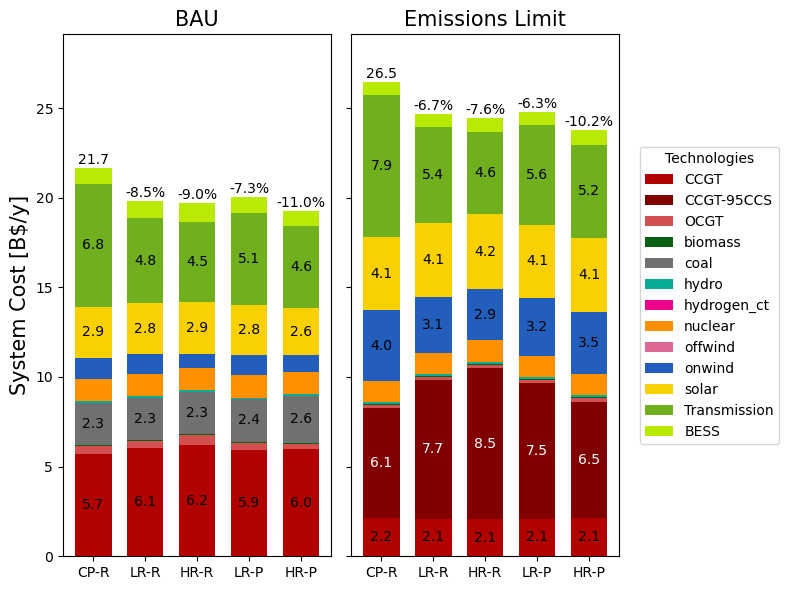

In [ ]:
# Create stacked bar plot of total costs
total_costs_dict

LABEL_FONT_SIZE = 10
TITLE_FONT_SIZE = 15

# Extract data for plotting
network_names = list(total_costs_dict.keys())
technologies = list(total_costs_dict[network_names[0]].index)

# define order of networks
network_names = ['Copperplate Reactive', 'LowRes Reactive', 'HighRes Reactive', 'LowRes Proactive', 'HighRes Proactive']
network_names_rem = ['Copperplate Reactive REM', 'LowRes Reactive REM', 'HighRes Reactive REM', 'LowRes Proactive REM', 'HighRes Proactive REM']
# Define alternate names for x-axis labels
network_labels = {
    'Copperplate Reactive': 'CP-R',
    'LowRes Reactive': 'LR-R',
    'HighRes Reactive': 'HR-R', 
    'LowRes Proactive': 'LR-P',
    'HighRes Proactive': 'HR-P'
}

# Add labels to plot
network_rem_labels = {
    'Copperplate Reactive REM': 'CP-R',
    'LowRes Reactive REM': 'LR-R',
    'HighRes Reactive REM': 'HR-R',
    'LowRes Proactive REM': 'LR-P', 
    'HighRes Proactive REM': 'HR-P'
}


# Create figure with two subplots side by side
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(8,6))

# Add titles to subplots
ax1.set_title('BAU', fontsize=TITLE_FONT_SIZE)
ax2.set_title('Emissions Limit', fontsize=TITLE_FONT_SIZE)

# First subplot - original networks
x1 = np.arange(len(network_names))
width = 0.7
bottom1 = np.zeros(len(network_names))

# Second subplot - REM networks  
x2 = np.arange(len(network_names_rem))
bottom2 = np.zeros(len(network_names_rem))

# Create stacked bars for each subplot
for tech in technologies:
    # Values for original networks
    values1 = [total_costs_dict[network].loc[tech][2040] /1e9 for network in network_names]
    if not np.isnan(values1).all():
        ax1.bar(x1, values1, width, bottom=bottom1, label=tech, color=color_map[tech])
        bottom1 += np.nan_to_num(values1)
        
    # Values for REM networks    
    values2 = [total_costs_dict[network].loc[tech][2040] /1e9 for network in network_names_rem]
    if not np.isnan(values2).all():
        ax2.bar(x2, values2, width, bottom=bottom2, label=tech, color=color_map[tech])
        bottom2 += np.nan_to_num(values2)


# Add value labels for first subplot
for i, network in enumerate(network_names):
    bottom = 0
    for tech in technologies:
        value = total_costs_dict[network].loc[tech][2040] / 1e9
        if not np.isnan(value) and abs(value) >= 1.5:
            height = value
            ax1.text(i, bottom + height/2, f'{value:.1f}', 
                    ha='center', va='center',
                    color='black', 
                    fontsize=LABEL_FONT_SIZE)
            bottom += height
        elif not np.isnan(value):
            bottom += value
            
# Add value labels for second subplot            
for i, network in enumerate(network_names_rem):
    bottom = 0
    for tech in technologies:
        value = total_costs_dict[network].loc[tech][2040] / 1e9
        if not np.isnan(value) and abs(value) >= 1.5:
            height = value
            if tech == 'CCGT-95CCS':
                TEXT_COLOR = 'white'
            else:
                TEXT_COLOR = 'black'
            ax2.text(i, bottom + height/2, f'{value:.1f}',
                    ha='center', va='center',
                    color=TEXT_COLOR,
                    fontsize=LABEL_FONT_SIZE)
            bottom += height
        elif not np.isnan(value):
            bottom += value

# Calculate totals for first subplot
total_heights1 = []
for network in network_names:
    total = 0
    for tech in technologies:
        value = total_costs_dict[network].loc[tech][2040] / 1e9
        if not np.isnan(value):
            total += value
    total_heights1.append(total)

# Calculate totals for second subplot    
total_heights2 = []
for network in network_names_rem:
    total = 0
    for tech in technologies:
        value = total_costs_dict[network].loc[tech][2040] / 1e9
        if not np.isnan(value):
            total += value
    total_heights2.append(total)

# Add total and reduction labels for first subplot
ax1.text(0, total_heights1[0] + 0.05, f'{total_heights1[0]:.1f}',
         ha='center', va='bottom',
         color='black',
         fontsize=LABEL_FONT_SIZE)

for i in range(1, len(network_names)):
    pct_reduction = ((total_heights1[0] - total_heights1[i]) / total_heights1[0]) * 100
    ax1.text(i, total_heights1[i] + 0.05, f'-{pct_reduction:.1f}%',
             ha='center', va='bottom', 
             color='black',
             fontsize=LABEL_FONT_SIZE)

# Add total and reduction labels for second subplot             
ax2.text(0, total_heights2[0] + 0.05, f'{total_heights2[0]:.1f}',
         ha='center', va='bottom',
         color='black', 
         fontsize=LABEL_FONT_SIZE)

for i in range(1, len(network_names_rem)):
    pct_reduction = ((total_heights2[0] - total_heights2[i]) / total_heights2[0]) * 100
    ax2.text(i, total_heights2[i] + 0.05, f'-{pct_reduction:.1f}%',
             ha='center', va='bottom',
             color='black',
             fontsize=LABEL_FONT_SIZE)


# Set x-axis labels
ax1.set_xticks(x1)
ax1.set_xticklabels([network_labels[n] for n in network_names])
ax2.set_xticks(x2) 
ax2.set_xticklabels([network_labels[n.replace(' REM','')] for n in network_names_rem])


# Add legend to right of second subplot
ax2.legend(bbox_to_anchor=(1.05, 0.5), loc='center left', title='Technologies')

# Set same y limits for both plots
max_height = max(max(total_heights1), max(total_heights2))
ax1.set_ylim(0, max_height * 1.1)
ax2.set_ylim(0, max_height * 1.1)

# set one y axis label
ax1.set_ylabel('System Cost [B$/y]', fontsize=TITLE_FONT_SIZE)
#remove y axis tick labels for second subplot
ax2.set_yticklabels([])
plt.tight_layout()

## Analyze price divergence in final networks

In [44]:
networks_bau = []
# networks_bau.add(n_cp_reactive)
networks_bau.append(n_lr_reactive)
networks_bau.append(n_hr_reactive)
networks_bau.append(n_lr_proactive)
networks_bau.append(n_hr_proactive)



In [41]:
n_hr_reactive.buses_t.marginal_price

Bus                            p600 0     p610 0     p610 1     p610 2  \
period timestep                                                          
2040   2040-01-01 00:00:00  18.399395  49.127840  10.999831  22.552738   
       2040-01-01 03:00:00   0.020205  26.778479   0.019924   5.581444   
       2040-01-01 06:00:00   0.020205   2.592983   0.020126   0.432421   
       2040-01-01 09:00:00   0.020216   0.019761   0.020126   0.020951   
       2040-01-01 12:00:00  20.923115  20.356629  20.514136  17.366155   
...                               ...        ...        ...        ...   
       2040-12-31 09:00:00   7.880433   0.019761   0.020126   0.020960   
       2040-12-31 12:00:00  23.820536  22.826938  22.399998  19.474990   
       2040-12-31 15:00:00  23.978031  23.133373  23.466485  19.515353   
       2040-12-31 18:00:00  22.789999  22.537006  22.634225  16.570410   
       2040-12-31 21:00:00  23.978031  24.195786  24.066047  19.625827   

Bus                            p620 0     p620 1     p620 2     p630 0  \
period timestep                                                          
2040   2040-01-01 00:00:00  19.510720  18.780754  20.243730  22.843725   
       2040-01-01 03:00:00   1.494126   1.121352   1.996269  22.843725   
       2040-01-01 06:00:00   0.172426   0.020538   0.212114  22.792824   
       2040-01-01 09:00:00   0.020668   0.020537   0.021040  22.843724   
       2040-01-01 12:00:00  20.869007  20.852494  20.425394  22.843725   
...                               ...        ...        ...        ...   
       2040-12-31 09:00:00   7.394017   0.020539   6.486369  22.843725   
       2040-12-31 12:00:00  23.401483  22.004155  22.909527  22.843725   
       2040-12-31 15:00:00  23.401486  23.485805  22.909529  22.843725   
       2040-12-31 18:00:00  22.132878  22.257890  21.419834  22.843725   
       2040-12-31 21:00:00  23.352118  23.487191  22.881112  22.843725   

Bus                            p630 1    p630 10  ...    p670 41    p670 42  \
period timestep                                   ...                         
2040   2040-01-01 00:00:00  22.134349  25.949176  ...  56.248386  32.527195   
       2040-01-01 03:00:00  22.134349  22.231029  ...  38.735951  26.913107   
       2040-01-01 06:00:00  22.134348  22.231029  ...  23.228165  23.310723   
       2040-01-01 09:00:00  22.134348  22.231029  ...  22.988039  23.175228   
       2040-01-01 12:00:00  22.158028  22.231033  ...  23.266321  23.344197   
...                               ...        ...  ...        ...        ...   
       2040-12-31 09:00:00  21.768236  25.772925  ...  34.971831  26.085549   
       2040-12-31 12:00:00  25.215687  25.426638  ...  44.228343  28.156366   
       2040-12-31 15:00:00  25.249896  25.456294  ...  39.000925  27.522956   
       2040-12-31 18:00:00  24.251130  24.308962  ...  37.578047  27.118699   
       2040-12-31 21:00:00  25.300042  25.415245  ...  44.228265  28.159945   

Bus                           p670 43    p670 44    p670 45     p670 5  \
period timestep                                                          
2040   2040-01-01 00:00:00  32.244422  32.173706  32.215660  26.452118   
       2040-01-01 03:00:00  26.692184  26.677612  26.679630  26.011216   
       2040-01-01 06:00:00  23.225776  23.184206  23.066704  23.151038   
       2040-01-01 09:00:00  23.092358  23.050715  22.943471  23.015834   
       2040-01-01 12:00:00  23.278913  23.291345  23.091544  23.279863   
...                               ...        ...        ...        ...   
       2040-12-31 09:00:00  25.899279  25.831658  25.811885  25.546286   
       2040-12-31 12:00:00  27.938723  27.865230  27.893717  27.142452   
       2040-12-31 15:00:00  27.341723  27.322398  27.182728  26.526921   
       2040-12-31 18:00:00  26.948786  26.934429  26.769128  26.185296   
       2040-12-31 21:00:00  27.942127  27.868312  27.898039  27.147543   

Bus                            p670 6     p670 7     p670 8     p670 9  
period tim